# HeatUp — Notebook 1: Getting Started

**Goal:** Run the full three-gate stability pipeline on a synthetic material 
using only NumPy — no real MLIP or DFT data required.

This notebook demonstrates:
- How to set up a HeatUp directory layout
- How to run `run_stability_pipeline()`
- How to interpret the three-panel dashboard
- How to adjust thresholds in `config.py`

---

In [1]:
import json
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt

# Install heatup if not already installed
# !pip install heatup
import heatup
import heatup.config as cfg
print(f'HeatUp version: {heatup.__version__}')

HeatUp version: 0.1.0


## 1. Build a synthetic material directory

HeatUp reads data from a standard directory layout. 
We create synthetic data that mimics what a real MACE workflow produces.

In [2]:
# ── Helper to write synthetic data files ────────────────────────────────────
def write_json(path, data):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)

# Create a temporary directory that mimics 'database/Li2ZrCl6/R-3m/'
base = tempfile.mkdtemp()
sym_dir = os.path.join(base, 'database', 'Li2ZrCl6', 'R-3m')
os.makedirs(sym_dir)
print(f'Symmetry directory: {sym_dir}')

Symmetry directory: /tmp/tmpxzjkdml_/database/Li2ZrCl6/R-3m


In [3]:
# ── 1a. POSCAR (minimal Li2ZrCl6 in R-3m) ──────────────────────────────────
poscar_content = """Li2ZrCl6 (R-3m)
1.0
   6.3800   0.0000   0.0000
  -3.1900   5.5250   0.0000
   0.0000   0.0000   9.7000
Li Zr Cl
2 1 6
Direct
0.000000 0.000000 0.250000
0.000000 0.000000 0.750000
0.000000 0.000000 0.000000
0.333333 0.666667 0.166667
0.666667 0.333333 0.833333
0.333333 0.666667 0.500000
0.666667 0.333333 0.500000
0.000000 0.000000 0.166667
0.000000 0.000000 0.833333
"""
with open(os.path.join(sym_dir, 'POSCAR'), 'w') as f:
    f.write(poscar_content)

# ── 1b. Relaxation energy ────────────────────────────────────────────────────
write_json(os.path.join(sym_dir, 'relaxation', 'energy.json'),
           {'energy_eV_per_atom': -3.847})

# ── 1c. Elastic tensor (Born-stable: all eigenvalues > 0) ──────────────────
C = np.zeros((6, 6))
C[0,0] = C[1,1] = C[2,2] = 62.5
C[0,1] = C[0,2] = C[1,2] = 18.0
C[3,3] = C[4,4] = C[5,5] = 15.0
C[1,0] = C[2,0] = C[2,1] = 18.0   # symmetric

eigvals = np.linalg.eigvalsh(C)
B = (C[0,0] + C[1,1] + C[2,2] + 2*(C[0,1]+C[0,2]+C[1,2])) / 9
G = (C[0,0]+C[1,1]+C[2,2]-C[0,1]-C[0,2]-C[1,2]+3*(C[3,3]+C[4,4]+C[5,5])) / 15

write_json(os.path.join(sym_dir, 'elastic', 'elastic_tensor.json'), {
    'elastic_tensor_GPa': C.tolist(),
    'derived_moduli': {
        'bulk_modulus_voigt_GPa'  : float(B),
        'shear_modulus_voigt_GPa' : float(G),
        'youngs_modulus_voigt_GPa': float(9*B*G/(3*B+G)),
        'poissons_ratio_voigt'    : float((3*B-2*G)/(2*(3*B+G))),
    }
})
print(f'Elastic tensor eigenvalues (GPa): {np.round(eigvals, 1)}')
print(f'B = {B:.1f} GPa,  G = {G:.1f} GPa  →', 'Born STABLE' if eigvals.min() > 0 else 'Born UNSTABLE')

Elastic tensor eigenvalues (GPa): [15.  15.  15.  44.5 44.5 98.5]
B = 32.8 GPa,  G = 17.9 GPa  → Born STABLE


In [4]:
# ── 1d. Anharmonic VDOS (stable: no soft-mode peak at ω=0) ─────────────────
rng = np.random.default_rng(42)
omega = np.linspace(0.5, 80, 400)   # meV

# Physically realistic VDOS for a heavy-atom halide (low frequency modes)
g = (0.8 * np.exp(-((omega - 15)**2) / 40)
   + 1.0 * np.exp(-((omega - 28)**2) / 60)
   + 0.5 * np.exp(-((omega - 45)**2) / 80))
g /= np.trapezoid(g, omega)

anh_dir = os.path.join(sym_dir, 'aimd', '900K', 'anharmonic_phonons')
os.makedirs(anh_dir)
write_json(os.path.join(anh_dir, 'vdos.json'),
           {'omega_mev': omega.tolist(), 'vdos': g.tolist()})

# ── 1e. Harmonic phonon DOS (fallback) ────────────────────────────────────
en = omega * 1e-3   # convert meV → eV for dos.json convention
write_json(os.path.join(sym_dir, 'phonons', 'dos.json'),
           {'energies_eV': en.tolist(), 'weights': g.tolist()})

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.fill_between(omega, 0, g, alpha=0.6, color='steelblue', label='Anharmonic VDOS')
ax.axvspan(0, 1, color='red', alpha=0.3, label='Soft-mode window')
ax.set_xlabel('ω (meV)')
ax.set_ylabel('VDOS (normalised)')
ax.set_title('Synthetic anharmonic VDOS — Li₂ZrCl₆')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1313044/1698397719.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 2. Run the stability pipeline

In [5]:
from heatup import run_stability_pipeline

report = run_stability_pipeline(
    sym_dir                 = sym_dir,
    operating_T             = 1200.0,
    generate_missing_phases = False,   # skip PyXtal for this quick demo
    save_figure             = True,
    figure_fmt              = 'png',
    device                  = 'cpu',
)

print('\n=== RESULT ===')
print(f'Overall verdict: {report["overall"].upper()}')
for flag in report.get('flags', []):
    print(f'  → {flag}')


  HeatUp Pipeline: Li2ZrCl6/R-3m
  Operating temperature : 1200 K

  [Gate 1] Mechanical stability...
    OK — Born stable — min eigenvalue 15.0 GPa, B = 32.8 GPa, G = 17.9 GPa.

  [Gate 2] Vibrational stability (anharmonic VDOS)...
    OK — No soft-mode signature detected (0.006% within |ω| < 1.0 meV). Vibrationally stable.

  [Gate 3] Thermodynamic stability (convex hull with T)...
    Scanning secondary phases (elements ⊆ {'Cl', 'Li', 'Zr'})...
    Found 0 existing competing phase(s).
    Preparing 0 competing phase(s)...
    0 phase(s) ready for hull.
    Building convex hull at 31 temperatures...
    MISSING — Could not evaluate hull (insufficient competing phases).

  Report → /tmp/tmpxzjkdml_/database/Li2ZrCl6/R-3m/stability/stability_report.json
  Overall: WARN
  Figure → /tmp/tmpxzjkdml_/database/Li2ZrCl6/R-3m/stability/stability_report.png

=== RESULT ===
Overall verdict: WARN
  → [MISSING] Thermodynamic: Could not evaluate hull (insufficient competing phases).


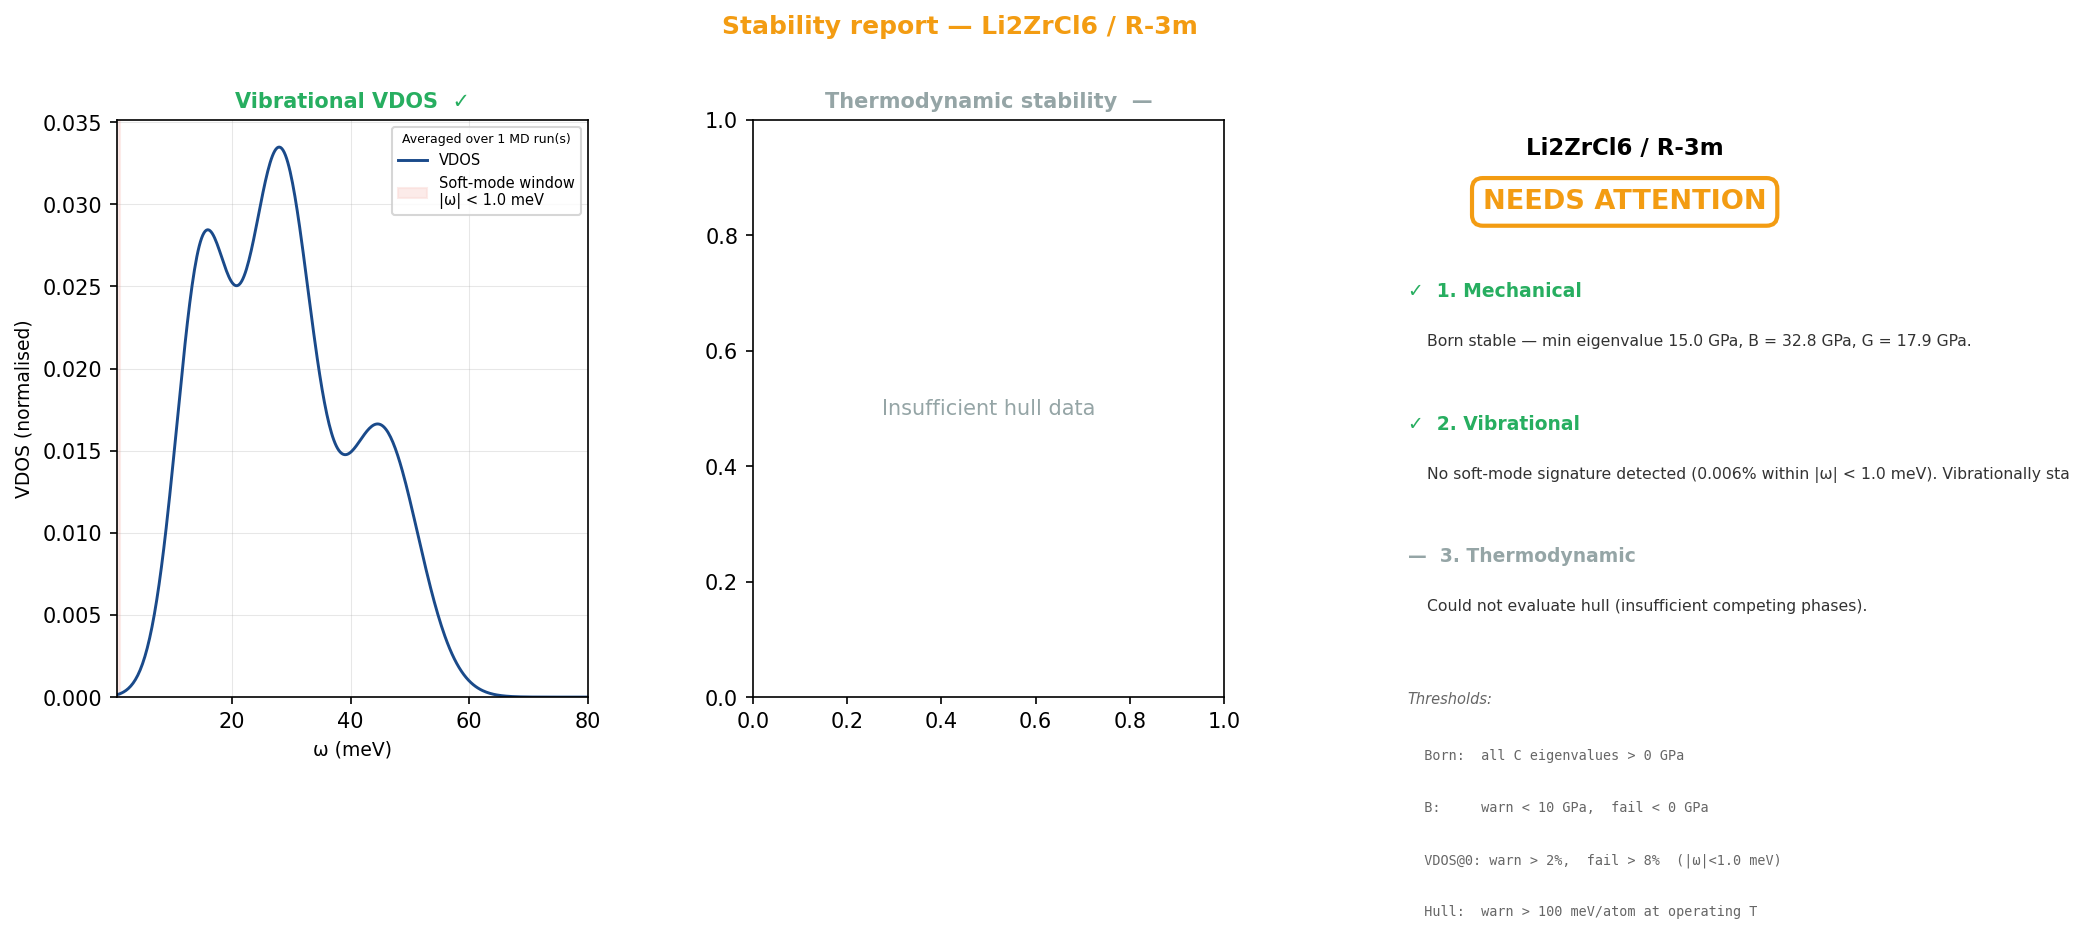

In [6]:
# ── Show the dashboard figure ────────────────────────────────────────────────
from IPython.display import Image
fig_path = os.path.join(sym_dir, 'stability', 'stability_report.png')
if os.path.exists(fig_path):
    display(Image(fig_path, width=900))

## 3. Inspect individual gate results

In [7]:
import pandas as pd

# Mechanical gate results
mech = report['mechanical']
print('Gate 1 — Mechanical')
print(f'  Status       : {mech["status"]}')
print(f'  Born stable  : {mech["born_stable"]}')
print(f'  Min eigenval : {mech["min_eigenvalue_GPa"]:.1f} GPa')
print(f'  B            : {mech["bulk_modulus_GPa"]:.1f} GPa')
print(f'  G            : {mech["shear_modulus_GPa"]:.1f} GPa')
print()

# Vibrational gate results
vib = report['vibrational']
print('Gate 2 — Vibrational')
print(f'  Status         : {vib["status"]}')
print(f'  Zero-mode frac : {vib["zero_window_frac"]*100:.3f}%')
print(f'  N sources      : {vib["n_sources"]}')

Gate 1 — Mechanical
  Status       : ok
  Born stable  : True
  Min eigenval : 15.0 GPa
  B            : 32.8 GPa
  G            : 17.9 GPa

Gate 2 — Vibrational
  Status         : ok
  Zero-mode frac : 0.006%
  N sources      : 1


## 4. Threshold sensitivity

All thresholds live in `config.py`. Let's explore how changing the
vibrational stability threshold affects the verdict.

In [8]:
from heatup.vibrational import assess_vibrational_stability

# Sweep the fail threshold
results = []
for thresh in np.linspace(0.001, 0.15, 20):
    cfg.VIB_ZERO_FRAC_FAIL = thresh
    vib_res = assess_vibrational_stability(sym_dir)
    results.append({'threshold': thresh * 100,
                    'frac_%': vib_res['zero_window_frac'] * 100,
                    'verdict': vib_res['status']})

cfg.VIB_ZERO_FRAC_FAIL = 0.08  # reset to default

df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.axhline(df['frac_%'].iloc[0], color='steelblue', ls='--', label='ζ (this material)')
verdicts = df['verdict'].unique()
for v, col in [('ok', 'green'), ('warn', 'orange'), ('fail', 'red')]:
    mask = df['verdict'] == v
    if mask.any():
        ax.scatter(df.loc[mask, 'threshold'], [1]*mask.sum(),
                   color=col, s=30, label=v, zorder=3)
ax.set_xlabel('Fail threshold (%)')
ax.set_yticks([])
ax.set_title('Vibrational verdict vs threshold')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1313044/358204067.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Summary

| Step | What we did |
|---|---|
| Directory setup | Created synthetic elastic tensor, VDOS, energy, POSCAR |
| Gate 1 | Born–Huang criterion: all eigenvalues > 0 → **pass** |
| Gate 2 | VDOS zero-mode fraction << 8% threshold → **pass** |
| Gate 3 | Not run (no competing phases in this demo) → **missing** |
| Threshold sweep | Showed how configuration changes verdict |

**Next:** See `02_gibbs_decomposition.ipynb` for the full GibbsAssembler workflow.